# Error scaling analysis: final figures

All error metrics are computed from the validation predictions stored in
`predictions/scenario_XXX_<size>.npz` (`val_preds`, `val_targets`; shape `(N, T, Z, X, 2)`,
channel 0 = concentration, channel 1 = hydraulic head). Metadata (parameter counts, `beta_c`, `D_c`)
comes from `sweep_results.csv` and the dataset manifest. Section 1 is the only exception: the npz files
contain no epoch information, so it reads the per-epoch loss-history JSON files.

1. Loss vs epoch per model size
2. Error scaling per scenario: (2a-2e) separate metrics, grouped by channel
3. Theory fits (orange: $a$ fixed, green: $K$ and $a$ free, red: bound $K^*$)
4. $\beta_C$ vs fitted $A$, $a$, $A^*$ (colour = $D_C$)

In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq, curve_fit

plt.style.use("default")

# ---- Paths ----
# BASE_RESULTS_PATH = Path("/scratch/yl75/$USER/results/groundwater/fno_3d_henry_sweep")
# BASE_DATA_PATH = Path("/scratch/yl75/$USER/data/simple_henry")
# BASE_RESULTS_PATH = Path("~/Projects/groundwater/results/fno_simple_henry_sweep").expanduser()
# BASE_DATA_PATH = Path("~/Projects/groundwater/data/simple_henry_data").expanduser()
BASE_RESULTS_PATH = Path("~/Projects/groundwater/results/fno_forced_henry_sweep").expanduser()
BASE_DATA_PATH = Path("~/Projects/groundwater/data/henry_forced_data").expanduser()

# RUN_NAME = "grid_scenarios_ic_random_skip2_20x40"
# DATASET_NAME = "grid_scenarios_ic_random_skip2_20x40"
RUN_NAME = "grid_scenarios_forced_random_skip2_20x40"
DATASET_NAME = "grid_scenarios_forced_random_skip2_20x40"

results_path = BASE_RESULTS_PATH / RUN_NAME
data_path = BASE_DATA_PATH / DATASET_NAME
prediction_npz_dir = results_path / "predictions"
fig_dir = results_path / "figures" / "final"
fig_dir.mkdir(parents=True, exist_ok=True)

# ---- Grid / time step used for the norms ----
DX = 0.05
DZ = 0.05
DT = 0.01       # T = 1.0 day: 50 solver steps of 0.02 d, skip = 2 -> 25 outputs

N_COLS = 4          # scenario grid columns
EXCLUDE_SCENARIOS = [] #[1, 2, 3, 4]   # dropped from every plot and fit
RECOMPUTE = False   # set True to ignore the cached metrics CSV
metrics_cache = results_path / f"npz_metrics_dt{DT:g}.csv"   # keyed on DT: changing DT recomputes

In [2]:
# ---- Metadata: model sizes and scenario parameters ----
sweep_df = pd.read_csv(results_path / "sweep_results.csv")
model_sizes = (
    sweep_df[["model_size_label", "total_params"]]
    .drop_duplicates()
    .sort_values("total_params")
    .reset_index(drop=True)
)
param_counts = model_sizes.set_index("model_size_label")["total_params"].to_dict()

manifest = json.load(open(data_path / "manifest.json"))["scenarios"]
scenarios_df = pd.DataFrame(manifest)[["scenario_index", "beta_c", "diffc"]]

model_sizes

,model_size_label,total_params
0,tiny,11094
1,small,68650
2,medium,1044850
3,large,8872930
4,huge,30454354


## Metric computation from npz files

In [3]:
def spatial_norms_sq(u):
    """Per-run (L^inf_t L^2_x)^2 and int_t ||grad u||_2^2 dt for u of shape (N, T, Z, X)."""
    area = DZ * DX
    l2_sq_space = np.sum(u ** 2, axis=(2, 3)) * area
    gz, gx = np.gradient(u, DZ, DX, axis=(2, 3))
    grad_sq_space = np.sum(gz ** 2 + gx ** 2, axis=(2, 3)) * area
    return np.max(l2_sq_space, axis=1), np.sum(grad_sq_space, axis=1) * DT


def head_sup_h1_norm(u):
    """Per-run sup_t ||u(t)||_{H^1} for u of shape (N, T, Z, X)."""
    area = DZ * DX
    l2_sq_space = np.sum(u ** 2, axis=(2, 3)) * area
    gz, gx = np.gradient(u, DZ, DX, axis=(2, 3))
    grad_sq_space = np.sum(gz ** 2 + gx ** 2, axis=(2, 3)) * area
    return np.max(np.sqrt(l2_sq_space + grad_sq_space), axis=1)


def rel_l2(target, pred):
    """Per-run relative L2 error over all of (T, Z, X); returns shape (N,)."""
    n = target.shape[0]
    diff = np.linalg.norm((pred - target).reshape(n, -1), axis=1)
    return diff / (np.linalg.norm(target.reshape(n, -1), axis=1) + 1e-12)


def compute_metrics(targets, preds):
    """All metrics for one (scenario, model) pair, each averaged over validation runs.

    Concentration norm  ||C||_{C_T}^2 = (L^inf L^2)^2 + int ||grad C||^2 dt.
    The two concentration components are normalised by the *full* true-solution norm, so
    conc_linf_l2^2 + conc_grad^2 = conc_norm^2.
    Head component is the relative sup_t H^1 norm. total_norm = conc_norm + head_norm.
    """
    t_c, p_c = targets[..., 0].astype(np.float64), preds[..., 0].astype(np.float64)
    t_h, p_h = targets[..., 1].astype(np.float64), preds[..., 1].astype(np.float64)

    linf_d, grad_d = spatial_norms_sq(p_c - t_c)
    linf_t, grad_t = spatial_norms_sq(t_c)
    true_c = np.sqrt(linf_t + grad_t)

    conc_norm = np.sqrt(linf_d + grad_d) / true_c
    head_norm = head_sup_h1_norm(p_h - t_h) / head_sup_h1_norm(t_h)

    return {
        "conc_rel_l2": rel_l2(t_c, p_c).mean(),
        "head_rel_l2": rel_l2(t_h, p_h).mean(),
        "conc_linf_l2": (np.sqrt(linf_d) / true_c).mean(),
        "conc_grad": (np.sqrt(grad_d) / true_c).mean(),
        "head_norm": head_norm.mean(),
        "conc_norm": conc_norm.mean(),
        "total_norm": (conc_norm + head_norm).mean(),
    }

In [4]:
if metrics_cache.exists() and not RECOMPUTE:
    metrics_df = pd.read_csv(metrics_cache)
else:
    rows = []
    for npz_file in sorted(prediction_npz_dir.glob("scenario_*.npz")):
        parts = npz_file.stem.split("_")
        scenario_index, size_label = int(parts[1]), parts[-1]
        with np.load(npz_file) as data:
            targets, preds = data["val_targets"], data["val_preds"]
        rows.append({"scenario_index": scenario_index, "model_size_label": size_label,
                     **compute_metrics(targets, preds)})
        print(f"done {npz_file.name}")
    metrics_df = pd.DataFrame(rows)
    metrics_df.to_csv(metrics_cache, index=False)

metrics_df = (
    metrics_df
    .merge(scenarios_df, on="scenario_index", how="left")
    .assign(total_params=lambda d: d["model_size_label"].map(param_counts))
    .query("scenario_index not in @EXCLUDE_SCENARIOS")
    .sort_values(["scenario_index", "total_params"])
    .reset_index(drop=True)
)
scenario_indices = sorted(metrics_df["scenario_index"].unique())
metrics_df.head()

,scenario_index,model_size_label,conc_rel_l2,head_rel_l2,conc_linf_l2,conc_grad,head_norm,conc_norm,total_norm,beta_c,diffc,total_params
0,1,tiny,0.116887,0.000553,0.086198,0.258571,0.004611,0.272858,0.277469,0.00035,0.05,11094
1,1,small,0.072568,0.000323,0.056183,0.165971,0.002822,0.175439,0.178261,0.00035,0.05,68650
2,1,medium,0.032696,0.000134,0.025326,0.087347,0.001487,0.091006,0.092493,0.00035,0.05,1044850
3,1,large,0.016311,0.000060,0.012533,0.049612,0.000858,0.051195,0.052053,0.00035,0.05,8872930
4,1,huge,0.011693,0.000043,0.009147,0.038511,0.000696,0.039600,0.040295,0.00035,0.05,30454354


## Plot helpers and theory fits

In [5]:
# Theoretical bound: P(eps) = K * eps^-a * (1 + log(1/eps))^2, a = 16 from theory,
# i.e. log(P/K) = -a log(eps) + 2 log(1 - log(eps)).
THEORY_EXP = 16


def theory_log_P_over_K(eps, exponent=THEORY_EXP):
    log_eps = np.log(eps)
    return -exponent * log_eps + 2 * np.log1p(-log_eps)


def theory_eps_from_P(P, K, exponent=THEORY_EXP):
    """Invert the bound numerically (root-find in log(eps) to avoid overflow)."""
    targets = np.log(np.asarray(P, dtype=float)) - np.log(K)

    def solve(t):
        u = brentq(lambda u: -exponent * u + 2 * np.log1p(-u) - t, -1000.0, 1.0 - 1e-12)
        return np.exp(u)

    return np.vectorize(solve)(targets)


def theory_K_envelope(P, eps, exponent=THEORY_EXP):
    """Smallest K (a fixed) for which the bound lies above every empirical point."""
    P = np.asarray(P, dtype=float)
    eps = np.asarray(eps, dtype=float)
    return np.exp(np.max(np.log(P) - theory_log_P_over_K(eps, exponent)))


def fit_theory_K(P, eps, exponent=THEORY_EXP):
    """Least-squares fit of K only (exponent fixed), in log(eps)."""
    P = np.asarray(P, dtype=float)
    eps = np.asarray(eps, dtype=float)
    log_K0 = np.mean(np.log(P) - theory_log_P_over_K(eps, exponent))

    def model(P, log_K):
        return np.log(theory_eps_from_P(P, np.exp(log_K), exponent))

    popt, _ = curve_fit(model, P, np.log(eps), p0=[log_K0])
    return np.exp(popt[0])


def fit_theory_K_exponent(P, eps):
    """Least-squares fit of (K, a) in log(eps)."""
    P = np.asarray(P, dtype=float)
    eps = np.asarray(eps, dtype=float)
    log_eps = np.log(eps)
    a0, log_K0 = np.polyfit(-log_eps, np.log(P) - 2 * np.log1p(-log_eps), 1)
    a0 = max(a0, 1e-2)

    def model(P, log_K, exponent):
        return np.log(theory_eps_from_P(P, np.exp(log_K), exponent))

    popt, _ = curve_fit(model, P, log_eps, p0=[log_K0, a0],
                        bounds=([-np.inf, 1e-3], [np.inf, np.inf]))
    return np.exp(popt[0]), popt[1]


def plot_theory_overlay(ax, P, eps, show_fixed=True):
    """Overlay the three theory curves; returns the fitted parameters (NaN if a fit fails)."""
    P_grid = np.logspace(np.log10(min(P)), np.log10(max(P)), 200)
    out = {"K_fit_fixed_exp": np.nan, "K_fit": np.nan, "exponent_fit": np.nan, "K_envelope": np.nan}

    try:  # orange: exponent fixed, K fitted
        out["K_fit_fixed_exp"] = fit_theory_K(P, eps)
        if show_fixed:
            ax.plot(P_grid, theory_eps_from_P(P_grid, out["K_fit_fixed_exp"]), color="orange", linestyle="--",
                    label=f"Fit $K$ ($a$={THEORY_EXP}, $K$={out['K_fit_fixed_exp']:.2e})")
    except Exception as exc:
        print(f"  fixed-exponent fit failed: {exc}")

    try:  # green: K and exponent fitted
        out["K_fit"], out["exponent_fit"] = fit_theory_K_exponent(P, eps)
        ax.plot(P_grid, theory_eps_from_P(P_grid, out["K_fit"], out["exponent_fit"]), color="green", linestyle=":",
                label=f"Fit $K, a$ ($a$={out['exponent_fit']:.2f}, $K$={out['K_fit']:.2e})")
    except Exception as exc:
        print(f"  free fit failed: {exc}")

    try:  # red: smallest K for which the curve upper-bounds every point
        out["K_envelope"] = theory_K_envelope(P, eps)
        ax.plot(P_grid, theory_eps_from_P(P_grid, out["K_envelope"]), color="red", linestyle="-.",
                label=f"Bound ($a$={THEORY_EXP}, $K^*$={out['K_envelope']:.2e})")
    except Exception as exc:
        print(f"  envelope failed: {exc}")
    return out


def compute_rayleigh_number(beta_c, diffc):
    K, delta_c, H, eta = 50, 35, 1, 0.35
    return (K * beta_c * delta_c * H) / (eta * diffc)


def scenario_grid(metric, ylabel, title, fname, theory=False, logy=False, paper=False):
    """One subplot per scenario: validation error vs total parameters.

    paper=True gives a compact publication layout: no suptitle (goes in the caption), no orange fit,
    one shared legend, fitted parameters annotated in each panel, shared axes, and a PDF saved next
    to the PNG. Panels are labelled by row ($\\beta_C$, left) and column ($D_C$, top) instead of
    per-panel titles, with $R_a$ in the top-right corner of each panel.
    Returns a DataFrame of fitted theory parameters (one row per scenario) when theory=True.
    """
    n = len(scenario_indices)
    n_rows = math.ceil(n / N_COLS)
    figsize = (3.1 * N_COLS, 1.75 * n_rows + 0.7) if paper else (4 * N_COLS, 2.2 * n_rows + 1)
    fit_rows = []

    with plt.rc_context({"font.size": 10} if paper else {}):
        fig, axes = plt.subplots(n_rows, N_COLS, figsize=figsize, sharex=True, sharey=paper,
                                 constrained_layout=True, squeeze=False)
        for ax in axes.flat[n:]:
            ax.set_visible(False)

        for i, (ax, s) in enumerate(zip(axes.flat, scenario_indices)):
            sub = metrics_df[metrics_df["scenario_index"] == s].sort_values("total_params")
            beta_c, diffc = sub["beta_c"].iloc[0], sub["diffc"].iloc[0]
            Ra = compute_rayleigh_number(beta_c, diffc)
            P, eps = sub["total_params"].to_numpy(), sub[metric].to_numpy()

            ax.plot(P, eps, color="blue", marker="o", label="Empirical")
            if theory:
                fit = plot_theory_overlay(ax, P, eps, show_fixed=not paper)
                fit_rows.append({"scenario_index": s, "beta_c": beta_c, "diffc": diffc, "Ra": Ra, **fit})
                if paper:
                    ax.text(0.04, 0.05,
                            f"$a$={fit['exponent_fit']:.2f}\n$A$={fit['K_fit']:.1e}\n$A^*$={fit['K_envelope']:.1e}",
                            transform=ax.transAxes, fontsize=8.5, va="bottom", ha="left",
                            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", alpha=0.9))
                else:
                    ax.legend(fontsize=6)

            on_bottom = (i + N_COLS >= n) if paper else True
            on_left = (i % N_COLS == 0) if paper else True
            if paper:
                if i < N_COLS:
                    ax.set_title(f"$D_C={diffc:g}$", fontsize=11)
                ax.set_ylabel(f"$\\beta_C={beta_c:g}$" if on_left else "", fontsize=10)
                ax.text(0.97, 0.94, f"$R_a$={Ra:.1f}", transform=ax.transAxes, fontsize=9,
                        va="top", ha="right")
                ax.yaxis.set_major_locator(plt.MaxNLocator(4))
            else:
                ax.set_title(f"$\\beta_C={beta_c:g}$, $D_C={diffc:g}$, $R_a={Ra:g}$", fontsize=9)
                ax.set_ylabel(ylabel)
                ax.set_xlabel("Total Parameters")
            ax.set_xscale("log")
            if logy:
                ax.set_yscale("log")
            ax.grid(True, which="both", linestyle="--", linewidth=0.5)
            if paper:
                ax.tick_params(labelbottom=on_bottom, labelleft=on_left)

        if paper:
            handles, _ = axes[0, 0].get_legend_handles_labels()
            fig.supylabel(ylabel, fontsize=12)
            fig.supxlabel("Total Parameters", fontsize=12)
            fig.legend(handles, ["Empirical", "Fit ($A$, $a$ free)", "Bound ($a$=16, $A^*$)"],
                       loc="outside upper center", ncol=3, fontsize=11, frameon=False)
        else:
            fig.suptitle(title, fontsize=13)

        fig.savefig(fig_dir / fname, bbox_inches="tight", dpi=300)
        if paper:
            fig.savefig(fig_dir / Path(fname).with_suffix(".pdf"), bbox_inches="tight")
        plt.show()
        plt.close(fig)
    return pd.DataFrame(fit_rows) if theory else None


## 1. Loss vs epoch per model size

The sweep trains one model per size on all scenarios jointly and writes a single
`{size}_loss_history.json` per size. If several history files exist for a size
(`{size}*_loss_history.json`, e.g. repeated runs), the line is the mean and the band is min-max;
with a single file only the line is drawn.

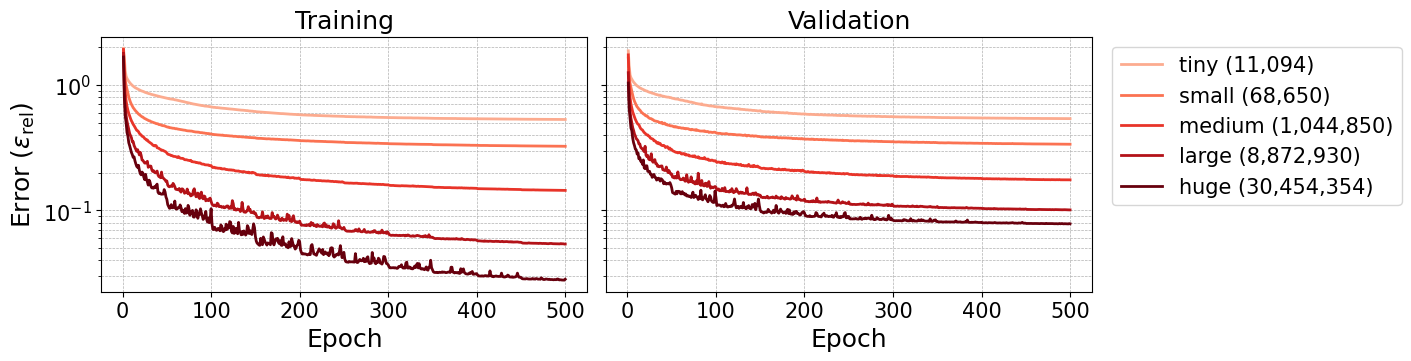

In [6]:
loss_dir = results_path / "figures"
colors = plt.cm.Reds(np.linspace(0.3, 1, len(model_sizes)))
history_panels = [
    ("train_rel_combined_norm_history", "Training"),
    ("val_rel_combined_norm_history", "Validation"),
]

with plt.rc_context({"font.size": 16, "axes.titlesize": 18, "axes.labelsize": 18,
                     "xtick.labelsize": 15, "ytick.labelsize": 15, "legend.fontsize": 15}):
    fig, axes = plt.subplots(1, 2, figsize=(14, 3.5), sharey=True, constrained_layout=True)

    for color, (label, params) in zip(colors, model_sizes.itertuples(index=False)):
        files = sorted(loss_dir.glob(f"{label}*_loss_history.json"))
        if not files:
            print(f"no loss history for {label}")
            continue
        histories = [json.load(open(f)) for f in files]

        for ax, (key, title) in zip(axes.flat, history_panels):
            stack = np.array([h[key] for h in histories])   # (n_files, n_epochs)
            epochs = np.arange(1, stack.shape[1] + 1)
            ax.plot(epochs, stack.mean(axis=0), color=color, linewidth=2, label=f"{label} ({params:,})")
            if len(stack) > 1:
                ax.fill_between(epochs, stack.min(axis=0), stack.max(axis=0), color=color, alpha=0.25)
            ax.set_title(title)

    for ax in axes.flat:
        ax.set_xlabel("Epoch")
        ax.set_yscale("log")
        ax.grid(True, which="both", linestyle="--", linewidth=0.5)
    axes[0].set_ylabel(r"Error ($\varepsilon_{\text{rel}}$)")
    axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))

    fig.savefig(fig_dir / "loss_vs_epoch.png", bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)

## 2. Error scaling per scenario

Each metric gets its own scenario grid. Concentration channel: 2a, 2c, 2d. Hydraulic head channel: 2b, 2e.
Components 2c and 2d are normalised by the full true concentration norm, so they combine in quadrature
to the concentration part of the total norm.

### Concentration channel

**2a.** Concentration relative L2 norm

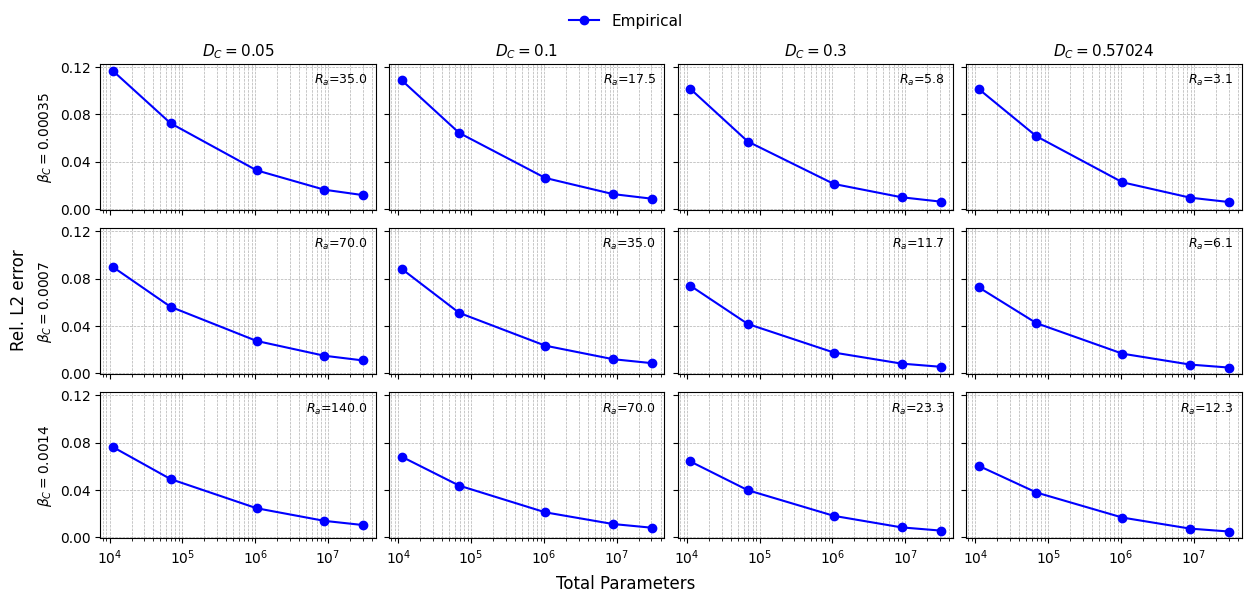

In [30]:
scenario_grid("conc_rel_l2", "Rel. L2 error",
              "Concentration relative L2 error vs model size (validation)",
              "scaling_2a_conc_rel_l2.png", paper=True)

**2c.** $L^\infty L^2$ component of the concentration norm

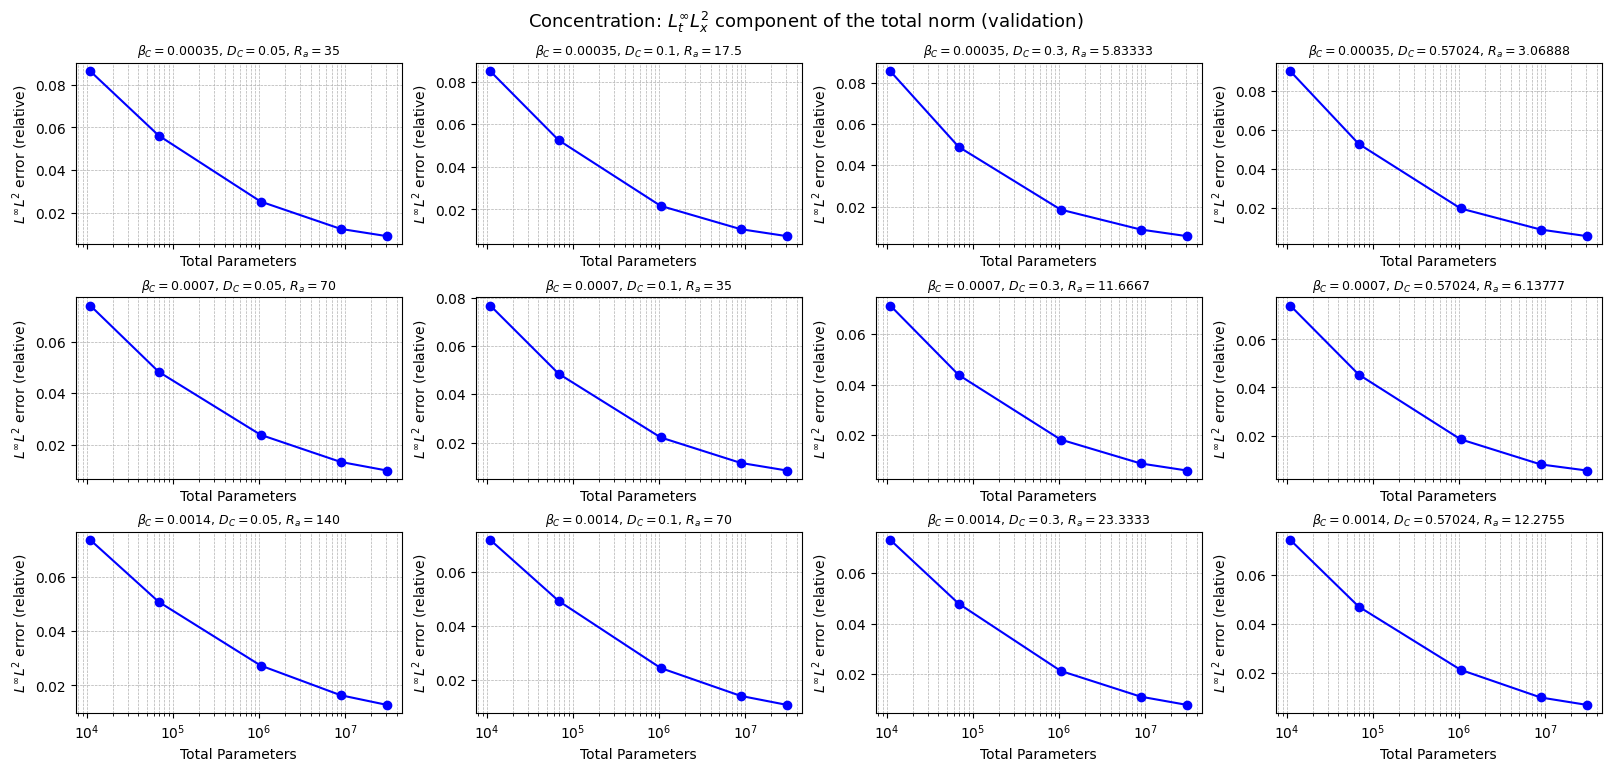

In [8]:
scenario_grid("conc_linf_l2", "$L^\\infty L^2$ error (relative)",
              "Concentration: $L^\\infty_t L^2_x$ component of the total norm (validation)",
              "scaling_2c_conc_linf_l2.png")

**2d.** Spatial-gradient component of the concentration norm

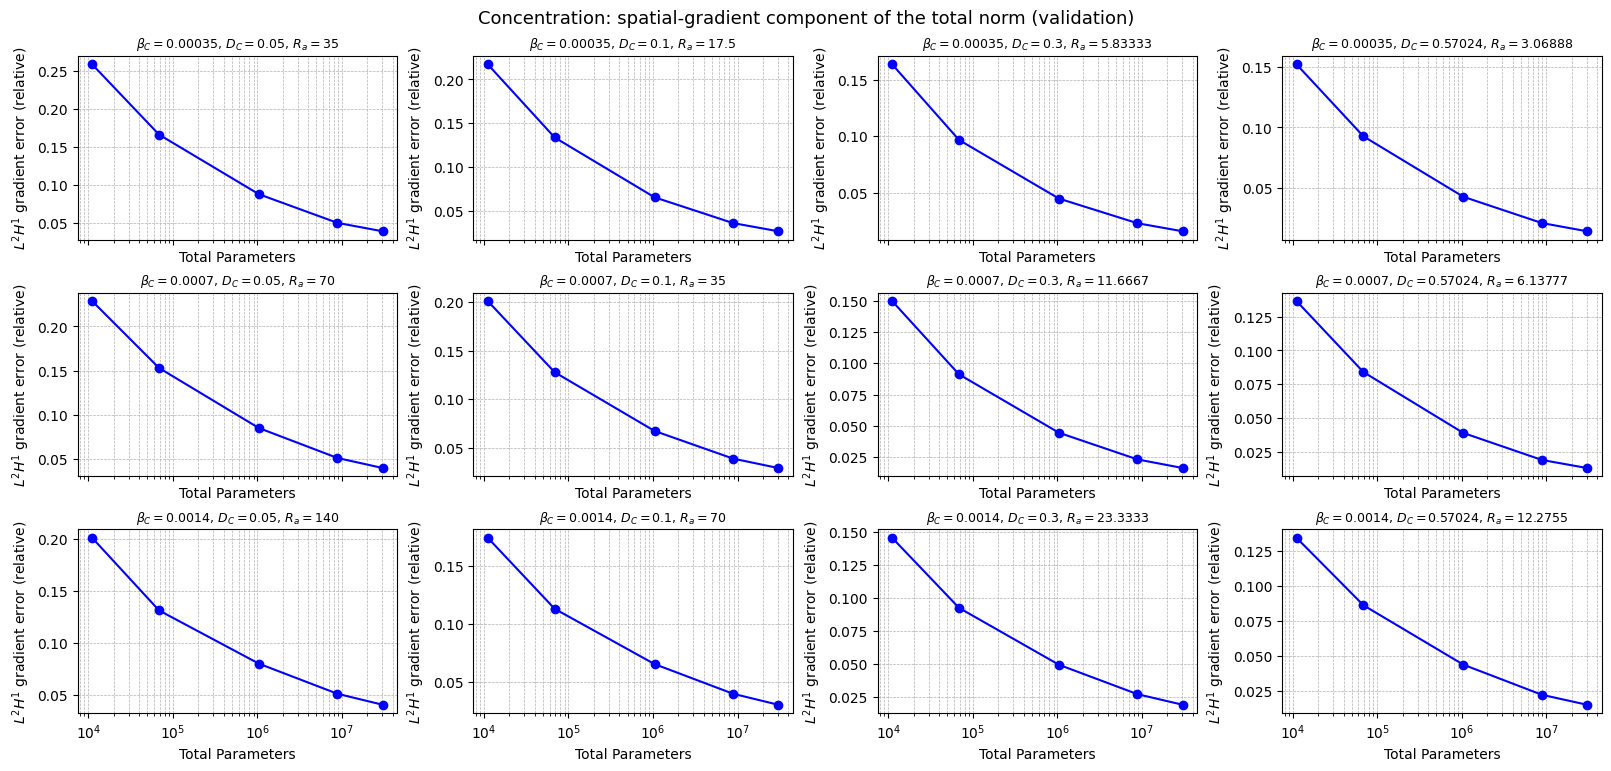

In [9]:
scenario_grid("conc_grad", "$L^2 H^1$ gradient error (relative)",
              "Concentration: spatial-gradient component of the total norm (validation)",
              "scaling_2d_conc_grad.png")

### Hydraulic head channel

**2b.** Hydraulic head relative L2 norm

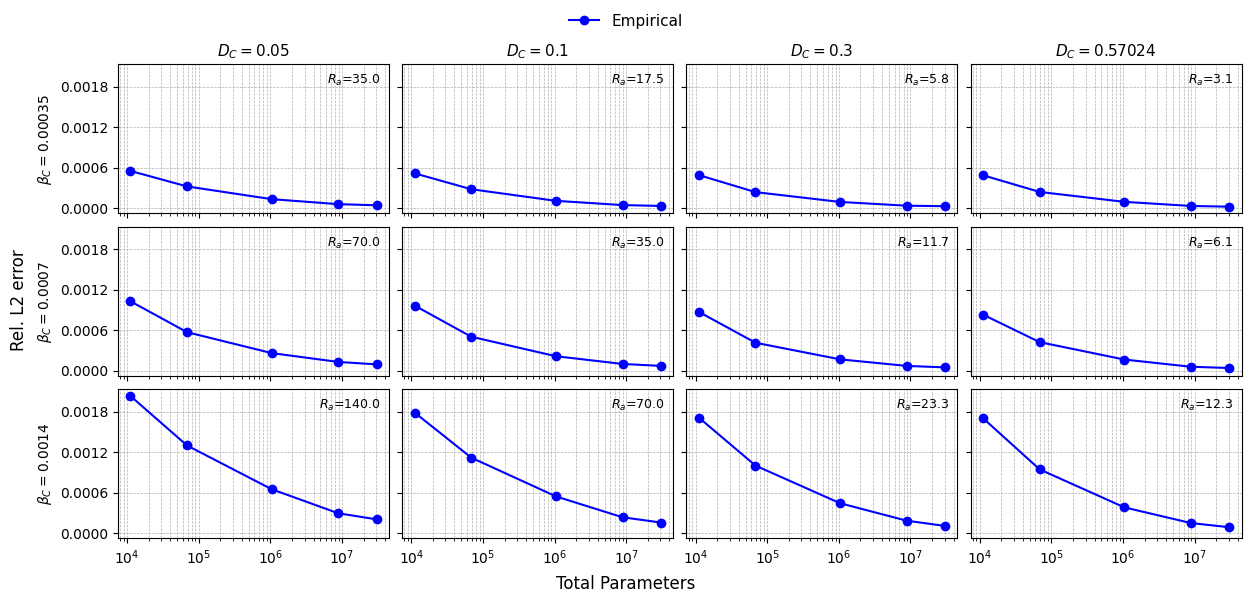

In [31]:
scenario_grid("head_rel_l2", "Rel. L2 error",
              "Hydraulic head relative L2 error vs model size (validation)",
              "scaling_2b_head_rel_l2.png", paper=True)

**2e.** Hydraulic head component of the total norm ($\sup_t H^1$, relative)

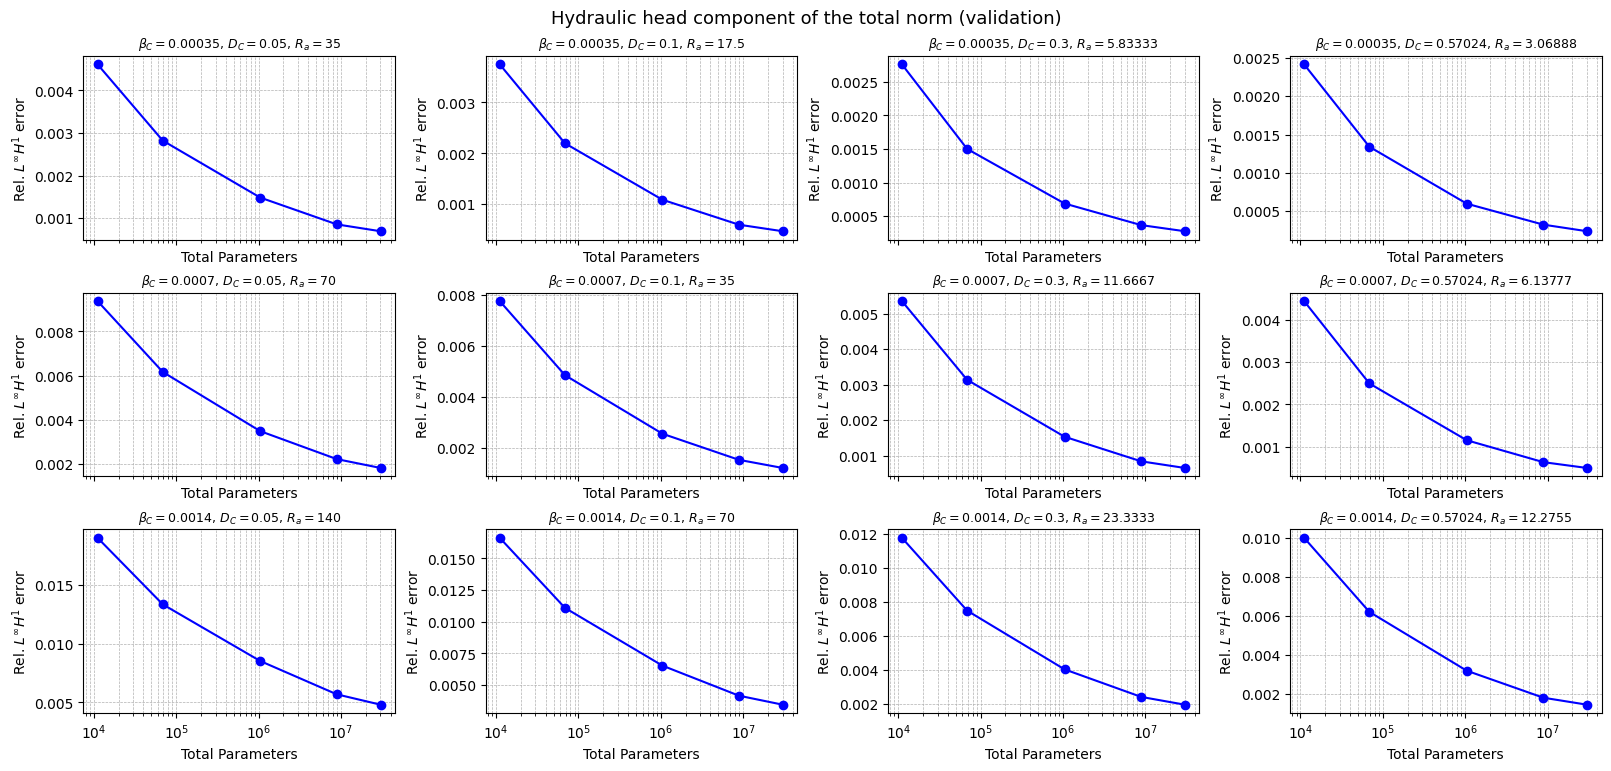

In [11]:
scenario_grid("head_norm", "Rel. $L^\\infty H^1$ error",
              "Hydraulic head component of the total norm (validation)",
              "scaling_2e_head_norm.png")

## 3. Theory fits

Orange: exponent fixed at $a=16$, $K$ fitted. Green: $K$ and $a$ fitted. Red: smallest $K^*$ ($a=16$)
whose curve upper-bounds every point.

**3a.** Concentration relative L2

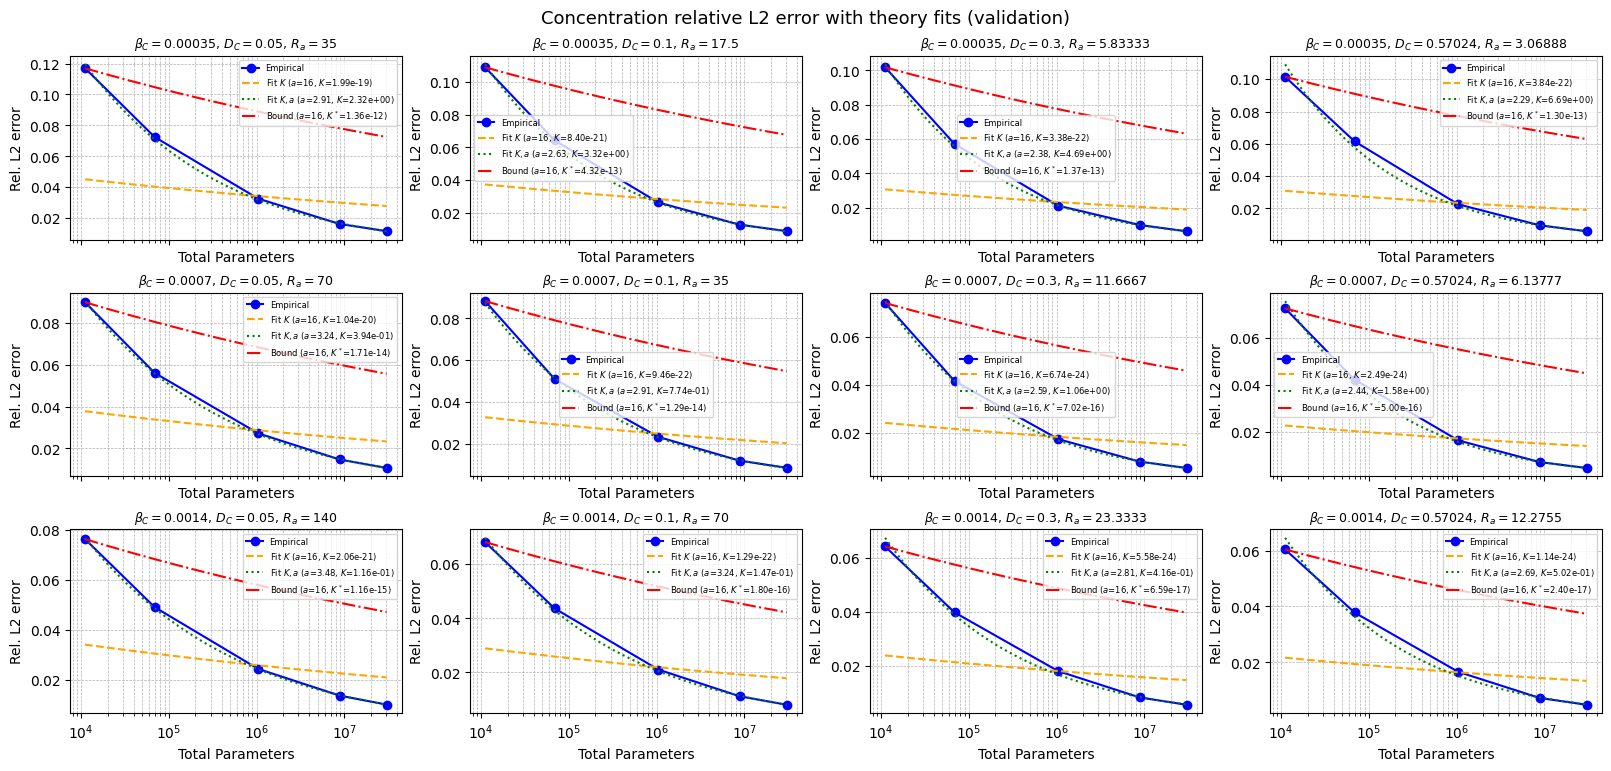

,scenario_index,beta_c,diffc,Ra,K_fit_fixed_exp,K_fit,exponent_fit,K_envelope
0,1,0.00035,0.05000,35.000000,1.991729e-19,2.321792,2.914670,1.360364e-12
1,2,0.00035,0.10000,17.500000,8.399653e-21,3.319501,2.632340,4.319272e-13
2,3,0.00035,0.30000,5.833333,3.381842e-22,4.687643,2.381225,1.366708e-13
3,4,0.00035,0.57024,3.068883,3.839233e-22,6.688731,2.292956,1.302523e-13
4,5,0.00070,0.05000,70.000000,1.042596e-20,0.393828,3.243378,1.708403e-14
5,6,0.00070,0.10000,35.000000,9.462273e-22,0.773539,2.914969,1.293680e-14
6,7,0.00070,0.30000,11.666667,6.738255e-24,1.056122,2.585602,7.024765e-16
7,8,0.00070,0.57024,6.137767,2.489123e-24,1.584325,2.441216,4.996347e-16
8,9,0.00140,0.05000,140.000000,2.062978e-21,0.116209,3.478310,1.156908e-15
9,10,0.00140,0.10000,70.000000,1.290357e-22,0.147217,3.243119,1.799773e-16


In [12]:
fits_conc = scenario_grid("conc_rel_l2", "Rel. L2 error",
                          "Concentration relative L2 error with theory fits (validation)",
                          "theory_3a_conc_rel_l2.png", theory=True)
fits_conc

**3b.** Hydraulic head relative L2

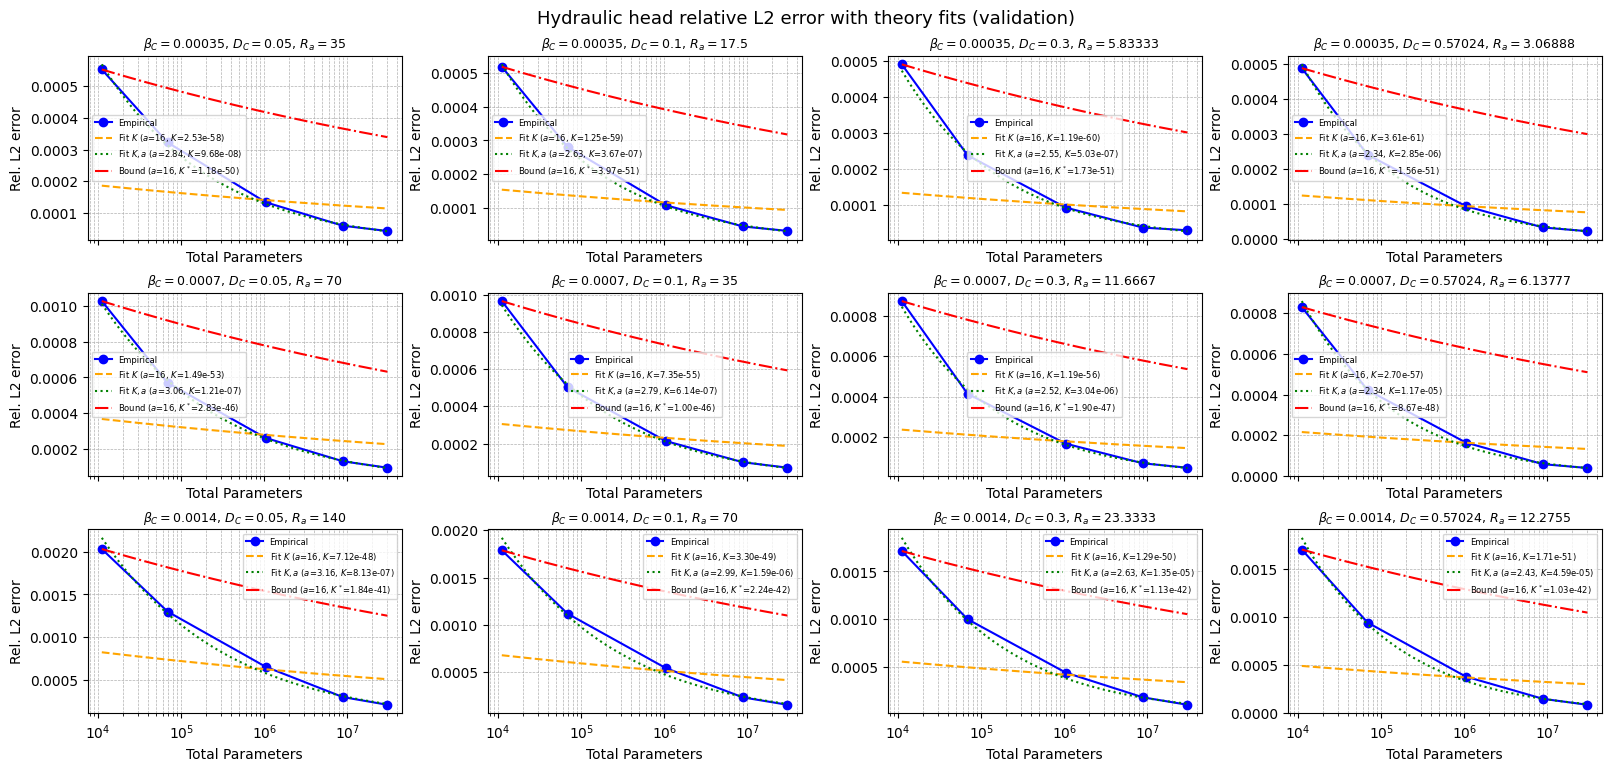

,scenario_index,beta_c,diffc,Ra,K_fit_fixed_exp,K_fit,exponent_fit,K_envelope
0,1,0.00035,0.05000,35.000000,2.533195e-58,9.679669e-08,2.836484,1.176850e-50
1,2,0.00035,0.10000,17.500000,1.251201e-59,3.669763e-07,2.626631,3.971178e-51
2,3,0.00035,0.30000,5.833333,1.186403e-60,5.030144e-07,2.547548,1.726720e-51
3,4,0.00035,0.57024,3.068883,3.610727e-61,2.850596e-06,2.338477,1.562683e-51
4,5,0.00070,0.05000,70.000000,1.487771e-53,1.212935e-07,3.061493,2.831637e-46
5,6,0.00070,0.10000,35.000000,7.353052e-55,6.144358e-07,2.794722,1.001996e-46
6,7,0.00070,0.30000,11.666667,1.191052e-56,3.040207e-06,2.520411,1.901078e-47
7,8,0.00070,0.57024,6.137767,2.704497e-57,1.174275e-05,2.336638,8.671998e-48
8,9,0.00140,0.05000,140.000000,7.120326e-48,8.125480e-07,3.163436,1.839165e-41
9,10,0.00140,0.10000,70.000000,3.303891e-49,1.593615e-06,2.989226,2.242910e-42


In [13]:
fits_head = scenario_grid("head_rel_l2", "Rel. L2 error",
                          "Hydraulic head relative L2 error with theory fits (validation)",
                          "theory_3b_head_rel_l2.png", theory=True)
fits_head

**3c.** Combined total norm

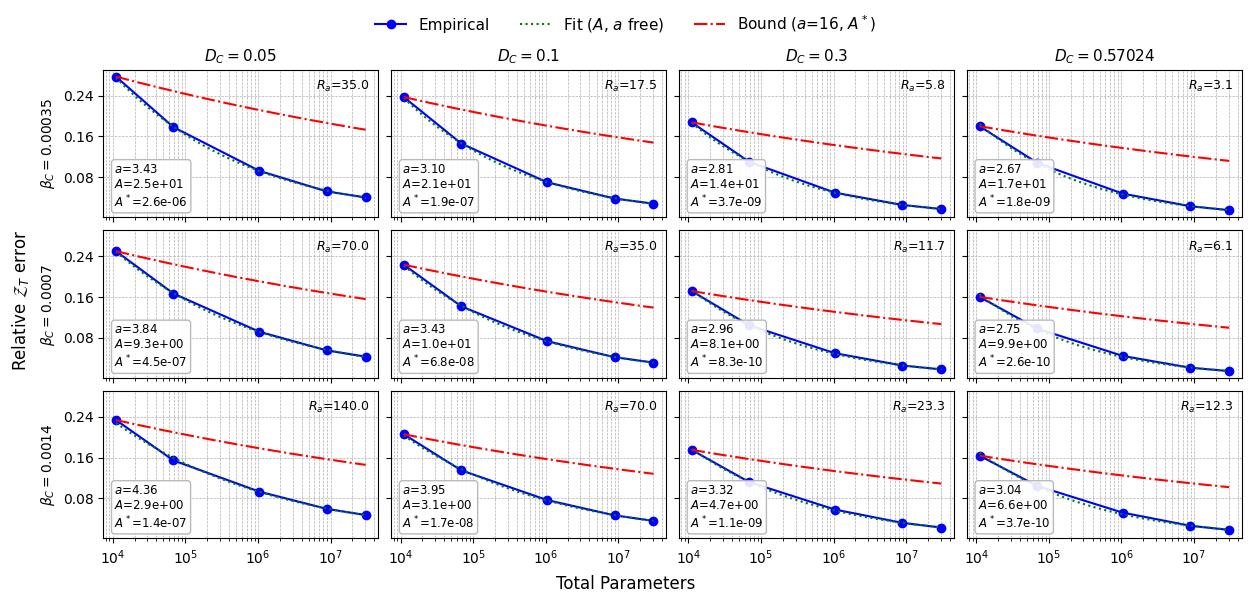

,scenario_index,beta_c,diffc,Ra,K_fit_fixed_exp,K_fit,exponent_fit,K_envelope
0,1,0.00035,0.05000,35.000000,5.790961e-12,25.319968,3.432865,2.629479e-06
1,2,0.00035,0.10000,17.500000,7.493602e-14,20.901851,3.099256,1.883387e-07
2,3,0.00035,0.30000,5.833333,2.467880e-16,13.944044,2.807793,3.659595e-09
3,4,0.00035,0.57024,3.068883,8.090685e-17,16.886517,2.669970,1.847949e-09
4,5,0.00070,0.05000,70.000000,4.739622e-12,9.287194,3.839419,4.526709e-07
5,6,0.00070,0.10000,35.000000,1.258576e-13,10.038358,3.429655,6.791117e-08
6,7,0.00070,0.30000,11.666667,1.613326e-16,8.149064,2.959418,8.255334e-10
7,8,0.00070,0.57024,6.137767,1.955081e-17,9.938351,2.752118,2.610743e-10
8,9,0.00140,0.05000,140.000000,5.353802e-12,2.854540,4.359036,1.448575e-07
9,10,0.00140,0.10000,70.000000,2.068027e-13,3.060212,3.946293,1.702983e-08


In [32]:
fits_total = scenario_grid("total_norm", r"Relative $\mathcal{Z}_T$ error",
                           "Combined total-norm error with theory fits (validation)",
                           "theory_3c_total_norm.png", theory=True, paper=True)
fits_total

**3d.** Concentration component of the total norm, $\|C_{pred}-C\|_{\mathcal{C}_T}/\|C\|_{\mathcal{C}_T}$ (paper layout)

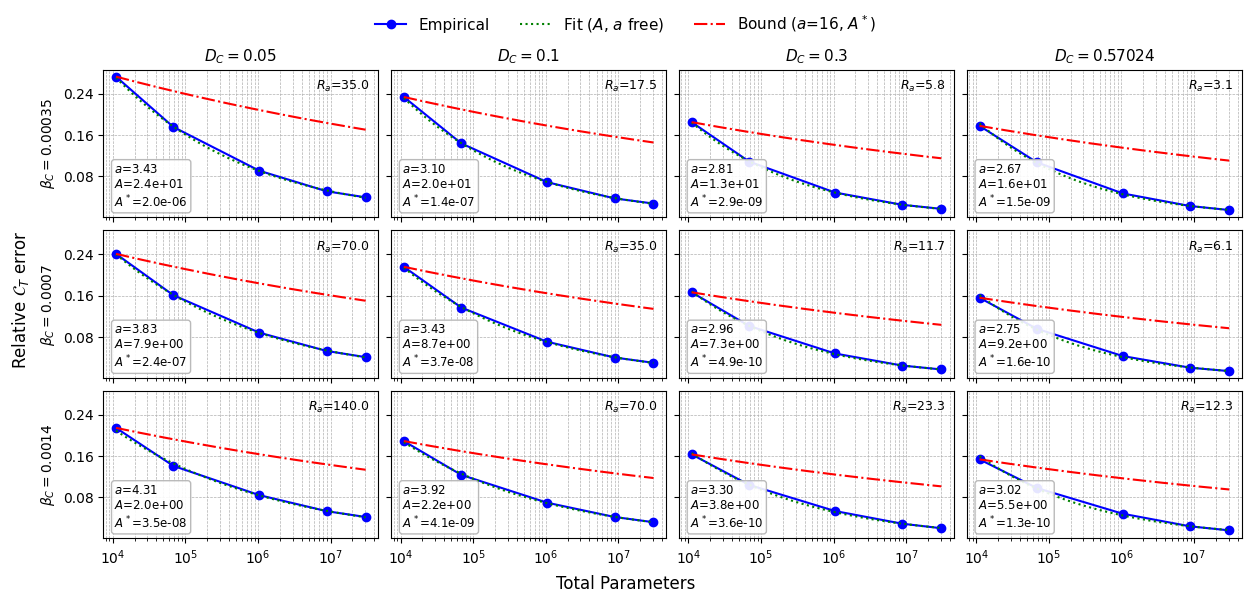

,scenario_index,beta_c,diffc,Ra,K_fit_fixed_exp,K_fit,exponent_fit,K_envelope
0,1,0.00035,0.05000,35.000000,4.397192e-12,23.572977,3.434610,1.981851e-06
1,2,0.00035,0.10000,17.500000,5.759436e-14,19.660453,3.100272,1.441055e-07
2,3,0.00035,0.30000,5.833333,1.939382e-16,13.260971,2.808283,2.855819e-09
3,4,0.00035,0.57024,3.068883,6.463270e-17,16.207150,2.669170,1.473926e-09
4,5,0.00070,0.05000,70.000000,2.445959e-12,7.878954,3.833820,2.379311e-07
5,6,0.00070,0.10000,35.000000,6.890667e-14,8.698748,3.428583,3.746059e-08
6,7,0.00070,0.30000,11.666667,9.396681e-17,7.337091,2.956355,4.859295e-10
7,8,0.00070,0.57024,6.137767,1.212461e-17,9.177288,2.747368,1.631292e-10
8,9,0.00140,0.05000,140.000000,1.087731e-12,1.982109,4.312548,3.469803e-08
9,10,0.00140,0.10000,70.000000,4.589921e-14,2.164412,3.921426,4.142938e-09


In [15]:
fits_conc_norm = scenario_grid("conc_norm", r"Relative $\mathcal{C}_T$ error",
                               "Concentration component of the total norm with theory fits (validation)",
                               "theory_3d_conc_norm.png", theory=True, paper=True)
fits_conc_norm

**3e.** Hydraulic head component of the total norm, $\|p_{pred}-p\|_{L^\infty H^1}/\|p\|_{L^\infty H^1}$ (paper layout)

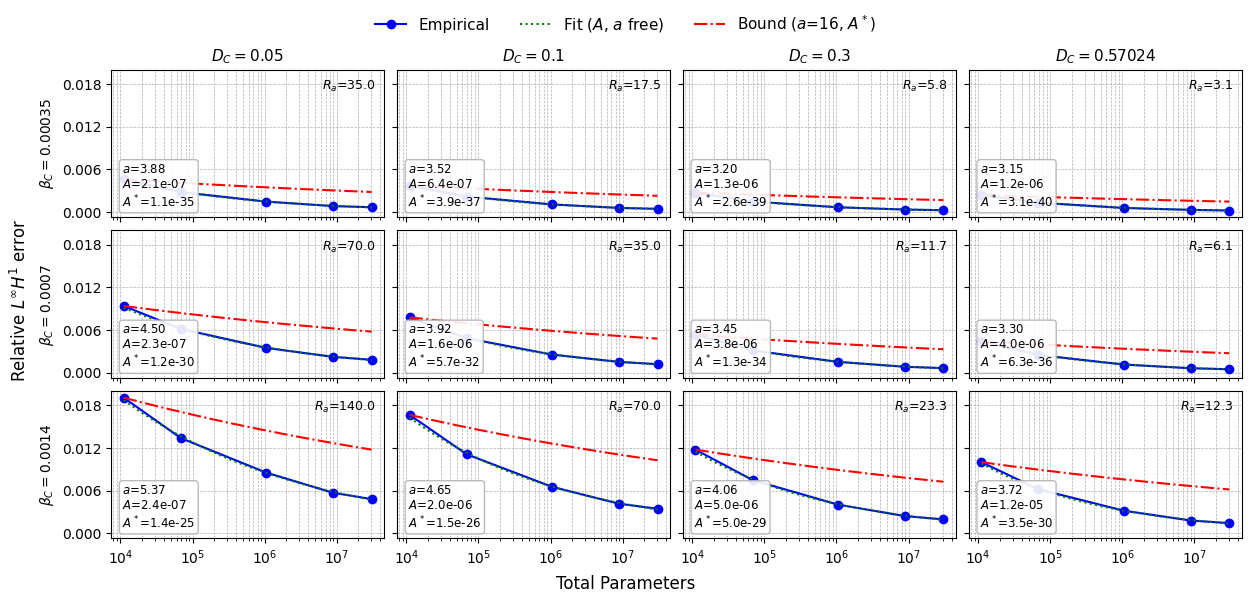

,scenario_index,beta_c,diffc,Ra,K_fit_fixed_exp,K_fit,exponent_fit,K_envelope
0,1,0.00035,0.05000,35.000000,3.349890e-41,2.108250e-07,3.876622,1.138189e-35
1,2,0.00035,0.10000,17.500000,2.369515e-43,6.447650e-07,3.522990,3.861091e-37
2,3,0.00035,0.30000,5.833333,2.148316e-46,1.324108e-06,3.195054,2.616713e-39
3,4,0.00035,0.57024,3.068883,2.245579e-47,1.165193e-06,3.147034,3.061844e-40
4,5,0.00070,0.05000,70.000000,3.552650e-35,2.311728e-07,4.497091,1.222327e-30
5,6,0.00070,0.10000,35.000000,2.350277e-37,1.564317e-06,3.920582,5.727294e-32
6,7,0.00070,0.30000,11.666667,6.072087e-41,3.834639e-06,3.446234,1.308411e-34
7,8,0.00070,0.57024,6.137767,1.010711e-42,4.028052e-06,3.297928,6.330596e-36
8,9,0.00140,0.05000,140.000000,4.233170e-29,2.370463e-07,5.369295,1.354045e-25
9,10,0.00140,0.10000,70.000000,7.398171e-31,2.002990e-06,4.653821,1.462848e-26


In [16]:
fits_head_norm = scenario_grid("head_norm", r"Relative $L^\infty H^1$ error",
                               "Hydraulic head component of the total norm with theory fits (validation)",
                               "theory_3e_head_norm.png", theory=True, paper=True)
fits_head_norm

## 4. Fit parameters vs $\beta_C$

$A$ and $a$ come from the free fit (green, $K$ and $a$ fitted), $A^*$ is the bound constant (red, $a=16$).
Colour encodes $D_C$.

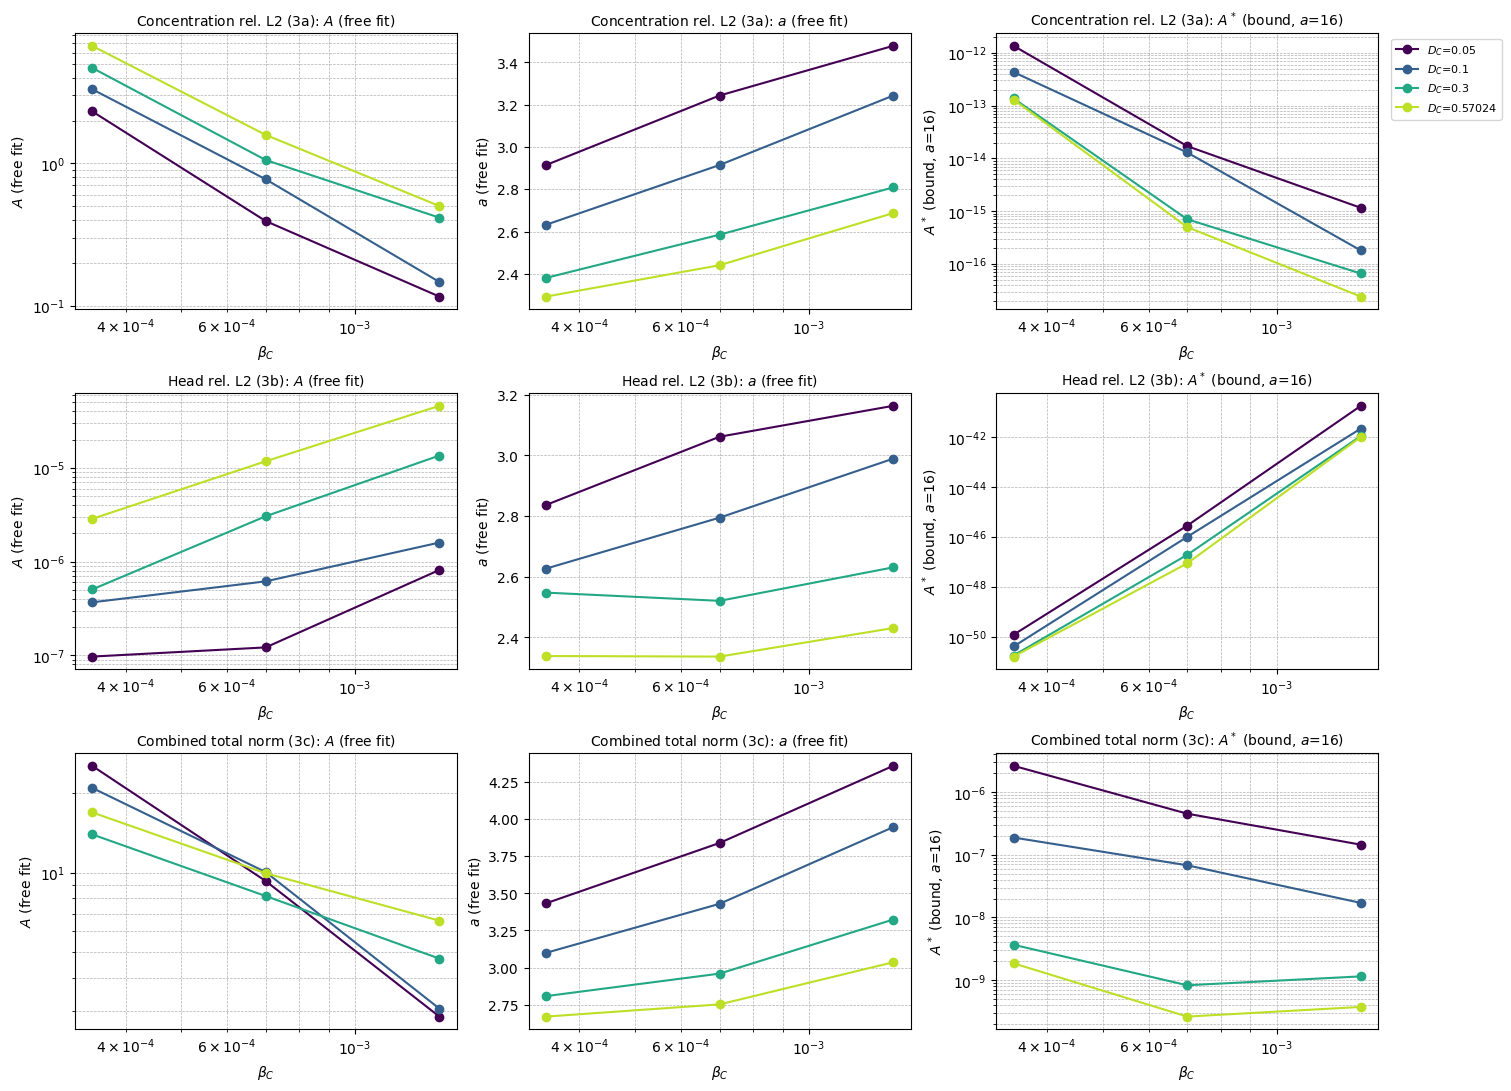

In [17]:
fit_sets = [("Concentration rel. L2 (3a)", fits_conc),
            ("Head rel. L2 (3b)", fits_head),
            ("Combined total norm (3c)", fits_total)]
param_cols = [("K_fit", "$A$ (free fit)", True),
              ("exponent_fit", "$a$ (free fit)", False),
              ("K_envelope", "$A^*$ (bound, $a$=16)", True)]

diffc_values = sorted(metrics_df["diffc"].unique())
diffc_colors = dict(zip(diffc_values, plt.cm.viridis(np.linspace(0, 0.9, len(diffc_values)))))

fig, axes = plt.subplots(len(fit_sets), len(param_cols), figsize=(15, 3.6 * len(fit_sets)),
                         constrained_layout=True, squeeze=False)

for row, (set_title, fdf) in enumerate(fit_sets):
    for col, (name, label, logy) in enumerate(param_cols):
        ax = axes[row, col]
        for diffc in diffc_values:
            sub = fdf[fdf["diffc"] == diffc].sort_values("beta_c")
            ax.plot(sub["beta_c"], sub[name], marker="o", color=diffc_colors[diffc], label=f"$D_C$={diffc:g}")
        ax.set_xscale("log")
        if logy:
            ax.set_yscale("log")
        ax.set_xlabel("$\\beta_C$")
        ax.set_ylabel(label)
        ax.set_title(f"{set_title}: {label}", fontsize=10)
        ax.grid(True, which="both", linestyle="--", linewidth=0.5)

axes[0, -1].legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.savefig(fig_dir / "fit_params_vs_beta_c.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close(fig)

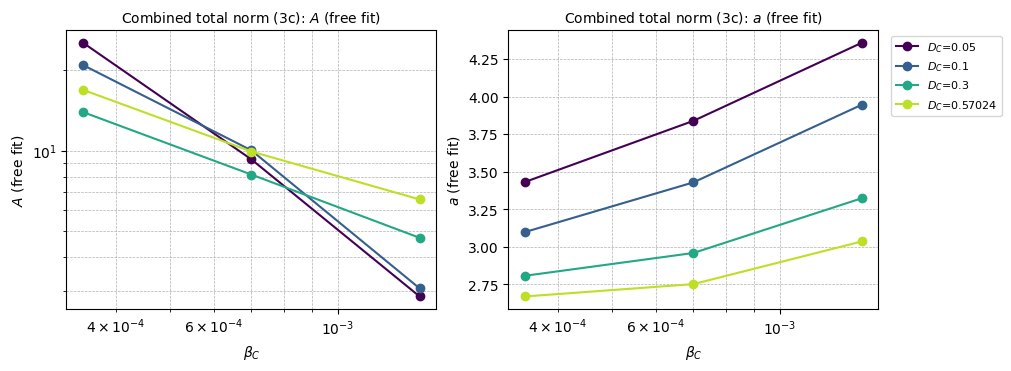

In [18]:
# --- Combined total norm (3c) only: A and a vs beta_C, colour = D_C ---
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), constrained_layout=True)

for ax, (name, label, logy) in zip(axes, param_cols[:2]):
    for diffc in diffc_values:
        sub = fits_total[fits_total["diffc"] == diffc].sort_values("beta_c")
        ax.plot(sub["beta_c"], sub[name], marker="o", color=diffc_colors[diffc], label=f"$D_C$={diffc:g}")
    ax.set_xscale("log")
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel("$\\beta_C$")
    ax.set_ylabel(label)
    ax.set_title(f"Combined total norm (3c): {label}", fontsize=10)
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)

axes[-1].legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.savefig(fig_dir / "fit_params_vs_beta_c_total_norm.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close(fig)

## 5. Paper figures

Compact figures for the main text, sized for a two-column page (7 in wide). They reuse `metrics_df`,
`fits_total` (3c) and `diffc_colors` (section 4), so run those cells first. Each figure is saved as PNG and PDF.

1. **5a.** Main scaling figure: all scenarios on one log-log panel, fitted rate $a$ vs $R_a$, constants vs $\beta_C$
2. **5b.** Error vs time within a trajectory, by $\beta_C$
3. **5c.** Concentration vs hydraulic head contributions to the $\mathcal{Z}_T$ error

Prediction snapshots are in the Appendix (A1) at the end of the notebook.

In [19]:
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D

PAPER_RC = {"font.size": 8, "axes.titlesize": 9, "axes.labelsize": 9, "xtick.labelsize": 7.5,
            "ytick.labelsize": 7.5, "legend.fontsize": 7.5}
beta_values = sorted(metrics_df["beta_c"].unique())
beta_colors = dict(zip(beta_values, plt.cm.plasma(np.linspace(0, 0.85, len(beta_values)))))


def save_paper_fig(fig, stem):
    fig.savefig(fig_dir / f"{stem}.png", bbox_inches="tight", dpi=300)
    fig.savefig(fig_dir / f"{stem}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

**5a.** Main scaling figure. (a) Relative $\mathcal{Z}_T$ error vs total parameters for every scenario,
coloured by $R_a$, with the theory rate ($a=16$) and the median free fit for reference, both anchored at the median
smallest-model error. (b) Fitted rate $a$ (free fit, 3c) vs $R_a$. (c) Fitted constant $A$ and bound constant $A^*$
vs $\beta_C$.

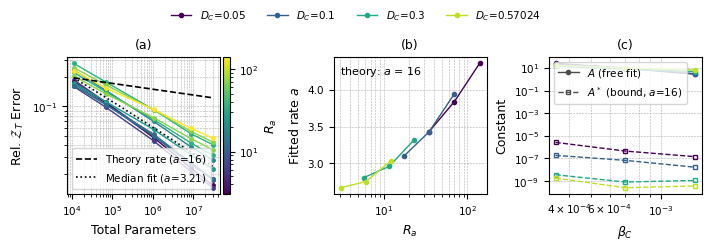

In [20]:
with plt.rc_context(PAPER_RC):
    fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.4), constrained_layout=True)

    # (a) every scenario on one log-log panel, coloured by R_a
    ax = axes[0]
    ra_norm = LogNorm(fits_total["Ra"].min(), fits_total["Ra"].max())
    for s in scenario_indices:
        sub = metrics_df[metrics_df["scenario_index"] == s].sort_values("total_params")
        Ra = compute_rayleigh_number(sub["beta_c"].iloc[0], sub["diffc"].iloc[0])
        ax.plot(sub["total_params"], sub["total_norm"], marker="o", ms=2.5, lw=1,
                color=plt.cm.viridis(ra_norm(Ra)))

    P_min, P_max = metrics_df["total_params"].min(), metrics_df["total_params"].max()
    P_grid = np.logspace(np.log10(P_min), np.log10(P_max), 200)
    eps0 = metrics_df.loc[metrics_df["total_params"] == P_min, "total_norm"].median()
    a_med = fits_total["exponent_fit"].median()
    for a, ls, lab in [(THEORY_EXP, "--", f"Theory rate ($a$={THEORY_EXP})"),
                       (a_med, ":", f"Median fit ($a$={a_med:.2f})")]:
        K = P_min / np.exp(theory_log_P_over_K(eps0, a))   # curve passes through (P_min, eps0)
        ax.plot(P_grid, theory_eps_from_P(P_grid, K, a), color="k", ls=ls, lw=1.2, label=lab)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Total Parameters")
    ax.set_ylabel(r"Rel. $\mathcal{Z}_T$ Error")
    ax.set_title("(a)")
    ax.legend(loc="lower left")
    ax.grid(True, which="both", linestyle="--", linewidth=0.4)
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=ra_norm, cmap="viridis"), ax=ax, pad=0.02)
    cbar.set_label("$R_a$")

    # (b) fitted rate a vs R_a, one line per D_C (increasing beta_C along each line)
    ax = axes[1]
    for diffc in diffc_values:
        sub = fits_total[fits_total["diffc"] == diffc].sort_values("Ra")
        ax.plot(sub["Ra"], sub["exponent_fit"], marker="o", ms=3, lw=1, color=diffc_colors[diffc],
                label=f"$D_C$={diffc:g}")
    ax.set_xscale("log")
    ax.set_xlabel("$R_a$")
    ax.set_ylabel("Fitted rate $a$")
    ax.set_title("(b)")
    ax.text(0.04, 0.95, f"theory: $a$ = {THEORY_EXP}", transform=ax.transAxes, va="top")
    ax.grid(True, which="both", linestyle="--", linewidth=0.4)

    # (c) fitted constant A and bound constant A* vs beta_C
    ax = axes[2]
    for diffc in diffc_values:
        sub = fits_total[fits_total["diffc"] == diffc].sort_values("beta_c")
        color = diffc_colors[diffc]
        ax.plot(sub["beta_c"], sub["K_fit"], marker="o", ms=3, lw=1, color=color)
        ax.plot(sub["beta_c"], sub["K_envelope"], marker="s", ms=3, lw=1, ls="--", color=color, mfc="none")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("$\\beta_C$")
    ax.set_ylabel("Constant")
    ax.set_title("(c)")
    ax.legend(handles=[Line2D([], [], color="0.3", marker="o", ms=3, lw=1, label="$A$ (free fit)"),
                       Line2D([], [], color="0.3", marker="s", ms=3, lw=1, ls="--", mfc="none",
                              label=f"$A^*$ (bound, $a$={THEORY_EXP})")],
              loc="upper left")
    ax.grid(True, which="both", linestyle="--", linewidth=0.4)

    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="outside upper center", ncol=len(diffc_values), frameon=False)
    save_paper_fig(fig, "paper_5a_scaling_summary")

**5b.** Error vs time. Each error is normalised by the sup-in-time norm of the true field, matching the
$L^\infty$-in-time parts of $\mathcal{Z}_T$: concentration $\|e_C(t)\|_{L^2}/\sup_t\|C(t)\|_{L^2}$ and head
$\|e_p(t)\|_{H^1}/\sup_t\|p(t)\|_{H^1}$, averaged over validation runs. Lines are the mean over $D_C$ for each
$\beta_C$; the band (largest model only) is the min-max over $D_C$. Output times are $t_k = k\,\Delta t$, $k=1,\dots,25$.

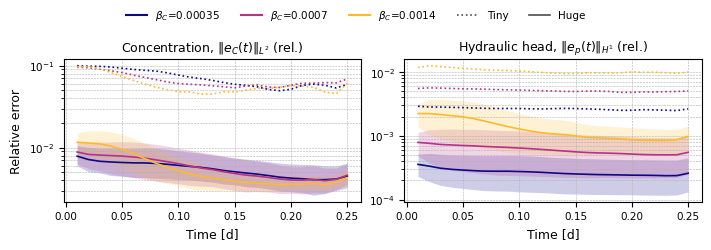

In [21]:
TIME_SIZES = ["tiny", "huge"]   # smallest and largest model


def l2_norm_t(u):
    """Per-run, per-time ||u(t)||_{L^2} for u of shape (N, T, Z, X); returns (N, T)."""
    return np.sqrt(np.sum(u ** 2, axis=(2, 3)) * DZ * DX)


def h1_norm_t(u):
    """Per-run, per-time ||u(t)||_{H^1} for u of shape (N, T, Z, X); returns (N, T)."""
    gz, gx = np.gradient(u, DZ, DX, axis=(2, 3))
    return np.sqrt(np.sum(u ** 2 + gz ** 2 + gx ** 2, axis=(2, 3)) * DZ * DX)


time_rows = []
for s in scenario_indices:
    for size in TIME_SIZES:
        with np.load(prediction_npz_dir / f"scenario_{s:03d}_{size}.npz") as data:
            targets = data["val_targets"].astype(np.float64)
            preds = data["val_preds"].astype(np.float64)
        t_c, t_h = targets[..., 0], targets[..., 1]
        conc_t = l2_norm_t(preds[..., 0] - t_c) / l2_norm_t(t_c).max(axis=1, keepdims=True)
        head_t = h1_norm_t(preds[..., 1] - t_h) / h1_norm_t(t_h).max(axis=1, keepdims=True)
        for k, (ec, eh) in enumerate(zip(conc_t.mean(axis=0), head_t.mean(axis=0)), start=1):
            time_rows.append({"scenario_index": s, "model_size_label": size, "t": k * DT,
                              "conc_t": ec, "head_t": eh})

time_df = pd.DataFrame(time_rows).merge(scenarios_df, on="scenario_index", how="left")

with plt.rc_context(PAPER_RC):
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.4), sharex=True, constrained_layout=True)
    for ax, col, title in zip(axes, ["conc_t", "head_t"],
                              [r"Concentration, $\|e_C(t)\|_{L^2}$ (rel.)", r"Hydraulic head, $\|e_p(t)\|_{H^1}$ (rel.)"]):
        for beta_c in beta_values:
            for size, ls in zip(TIME_SIZES, [":", "-"]):
                agg = (time_df.query("beta_c == @beta_c and model_size_label == @size")
                       .groupby("t")[col].agg(["mean", "min", "max"]))
                ax.plot(agg.index, agg["mean"], color=beta_colors[beta_c], ls=ls, lw=1.2)
                if size == TIME_SIZES[-1]:
                    ax.fill_between(agg.index, agg["min"], agg["max"], color=beta_colors[beta_c], alpha=0.2, lw=0)
        ax.set_yscale("log")
        ax.set_xlabel("Time [d]")
        ax.set_title(title)
        ax.grid(True, which="both", linestyle="--", linewidth=0.4)
    axes[0].set_ylabel("Relative error")

    handles = [Line2D([], [], color=beta_colors[b], lw=1.5, label=f"$\\beta_C$={b:g}") for b in beta_values]
    handles += [Line2D([], [], color="0.3", ls=ls, lw=1.2, label=size.capitalize())
                for size, ls in zip(TIME_SIZES, [":", "-"])]
    fig.legend(handles=handles, loc="outside upper center", ncol=len(handles), frameon=False)
    save_paper_fig(fig, "paper_5b_error_vs_time")

**5c.** Concentration vs hydraulic head contributions. (a) The two parts of the $\mathcal{Z}_T$ error,
$\|e_C\|_{\mathcal{C}_T}/\|C\|_{\mathcal{C}_T}$ (solid) and $\|e_p\|_{L^\infty H^1}/\|p\|_{L^\infty H^1}$ (dashed),
vs total parameters, mean over $D_C$ for each $\beta_C$. (b) Head share of the $\mathcal{Z}_T$ error vs $\beta_C$ for
each model size; band is min-max over $D_C$.

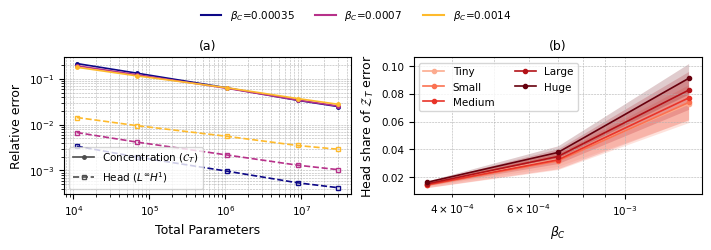

In [22]:
with plt.rc_context(PAPER_RC):
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.4), constrained_layout=True)

    # (a) concentration and head parts vs model size
    ax = axes[0]
    parts = metrics_df.groupby(["beta_c", "total_params"], as_index=False)[["conc_norm", "head_norm"]].mean()
    for beta_c in beta_values:
        sub = parts[parts["beta_c"] == beta_c]
        ax.plot(sub["total_params"], sub["conc_norm"], marker="o", ms=2.5, lw=1.2, color=beta_colors[beta_c])
        ax.plot(sub["total_params"], sub["head_norm"], marker="s", ms=2.5, lw=1.2, ls="--",
                color=beta_colors[beta_c], mfc="none")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Total Parameters")
    ax.set_ylabel("Relative error")
    ax.set_title("(a)")
    ax.legend(handles=[Line2D([], [], color="0.3", marker="o", ms=2.5, lw=1.2, label=r"Concentration ($\mathcal{C}_T$)"),
                       Line2D([], [], color="0.3", marker="s", ms=2.5, lw=1.2, ls="--", mfc="none",
                              label=r"Head ($L^\infty H^1$)")],
              loc="lower left")
    ax.grid(True, which="both", linestyle="--", linewidth=0.4)

    # (b) head share of the total error vs beta_C, per model size
    ax = axes[1]
    share = (metrics_df.assign(head_share=lambda d: d["head_norm"] / d["total_norm"])
             .groupby(["total_params", "model_size_label", "beta_c"])["head_share"]
             .agg(["mean", "min", "max"]).reset_index())
    for color, (label, params) in zip(colors, model_sizes.itertuples(index=False)):
        sub = share[share["model_size_label"] == label].sort_values("beta_c")
        ax.plot(sub["beta_c"], sub["mean"], marker="o", ms=3, lw=1.2, color=color, label=label.capitalize())
        ax.fill_between(sub["beta_c"], sub["min"], sub["max"], color=color, alpha=0.2, lw=0)
    ax.set_xscale("log")
    ax.set_xlabel("$\\beta_C$")
    ax.set_ylabel(r"Head share of $\mathcal{Z}_T$ error")
    ax.set_title("(b)")
    ax.legend(loc="best", ncol=2)
    ax.grid(True, which="both", linestyle="--", linewidth=0.4)

    handles = [Line2D([], [], color=beta_colors[b], lw=1.5, label=f"$\\beta_C$={b:g}") for b in beta_values]
    fig.legend(handles=handles, loc="outside upper center", ncol=len(handles), frameon=False)
    save_paper_fig(fig, "paper_5c_error_split")

**5e.** Compact version of the 3c scenario grid: one panel per $D_C$, with all $\beta_C$ values as lines
(validation, relative $\mathcal{Z}_T$ error vs total parameters).

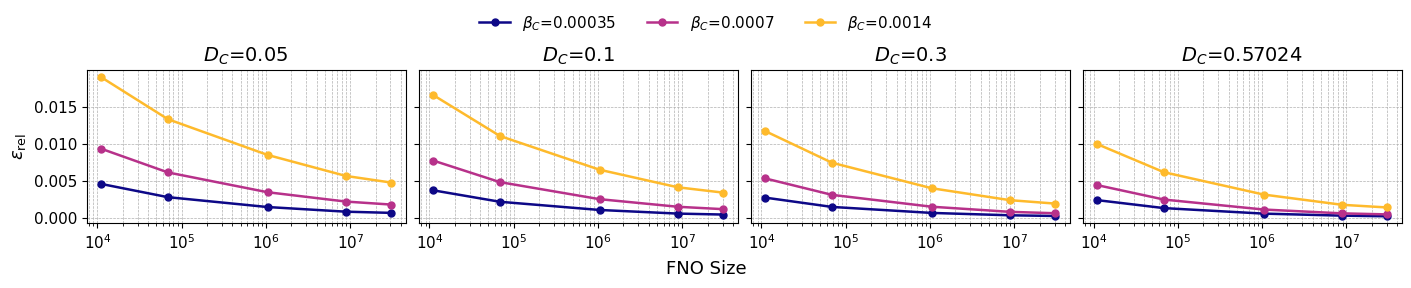

In [38]:
LOGY_5E = False

FONT_5E = {
    **PAPER_RC,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
}
MS_5E, LW_5E = 5, 1.8   # marker size / line width shared by the 5e-style figures below

with plt.rc_context(FONT_5E):
    fig, axes = plt.subplots(
        1, len(diffc_values), figsize=(14.0, 2.8),
        sharex=True, sharey=True, constrained_layout=True
    )

    for ax, diffc in zip(axes, diffc_values):
        for beta_c in beta_values:
            sub = metrics_df.query(
                "diffc == @diffc and beta_c == @beta_c"
            ).sort_values("total_params")
            ax.plot(
                sub["total_params"], sub["head_norm"],
                marker="o", ms=MS_5E, lw=LW_5E,
                color=beta_colors[beta_c],
                label=f"$\\beta_C$={beta_c:g}"
            )

        ax.set_title(f"$D_C$={diffc:g}")
        ax.set_xscale("log")
        # ax.set_yscale("log")
        if LOGY_5E:
            ax.set_yscale("log")
        ax.grid(True, which="both", linestyle="--", linewidth=0.5)

    axes[0].set_ylabel(r"$\varepsilon_{\text{rel}}$")
    fig.supxlabel("FNO Size", fontsize=13)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc="outside upper center",
        ncol=len(beta_values), frameon=False, fontsize=11
    )

    save_paper_fig(fig, "paper_5e_head_scaling_by_diffc")

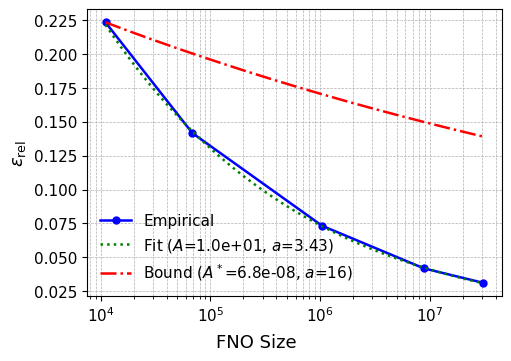

In [24]:
# --- Single scenario (beta_C = 7e-5, D_C = 0.003): relative Z_T error with free fit (green) and bound (red) ---
# BETA_SINGLE, DIFFC_SINGLE = 7e-5, 0.003
BETA_SINGLE, DIFFC_SINGLE = 0.0007,0.10000


sub = metrics_df[np.isclose(metrics_df["beta_c"], BETA_SINGLE)
                 & np.isclose(metrics_df["diffc"], DIFFC_SINGLE)].sort_values("total_params")
if sub.empty:
    available = metrics_df[["beta_c", "diffc"]].drop_duplicates().sort_values(["beta_c", "diffc"])
    raise ValueError(f"No runs for beta_C={BETA_SINGLE:g}, D_C={DIFFC_SINGLE:g} in this dataset; "
                     f"available pairs:\n{available.to_string(index=False)}")
P, eps = sub["total_params"].to_numpy(), sub["total_norm"].to_numpy()
Ra = compute_rayleigh_number(BETA_SINGLE, DIFFC_SINGLE)

with plt.rc_context(FONT_5E):
    fig, ax = plt.subplots(figsize=(5.0, 3.5), constrained_layout=True)
    ax.plot(P, eps, color="blue", marker="o", ms=MS_5E, lw=LW_5E, label="Empirical")
    fit = plot_theory_overlay(ax, P, eps, show_fixed=False)
    for line in ax.get_lines()[1:]:   # theory curves
        line.set_linewidth(LW_5E)
    ax.set_xscale("log")
    ax.set_ylabel(r"$\varepsilon_{\text{rel}}$")
    # ax.set_title(f"$\\beta_C$={BETA_SINGLE:g}, $D_C$={DIFFC_SINGLE:g}, $R_a$={Ra:.1f}")
    ax.legend(handles=ax.get_lines(),
              labels=["Empirical",
                      f"Fit ($A$={fit['K_fit']:.1e}, $a$={fit['exponent_fit']:.2f})",
                      f"Bound ($A^*$={fit['K_envelope']:.1e}, $a$={THEORY_EXP})"],
              frameon=False)
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)
    fig.supxlabel("FNO Size", fontsize=13)
    save_paper_fig(fig, f"theory_single_beta{BETA_SINGLE:g}_diffc{DIFFC_SINGLE:g}")

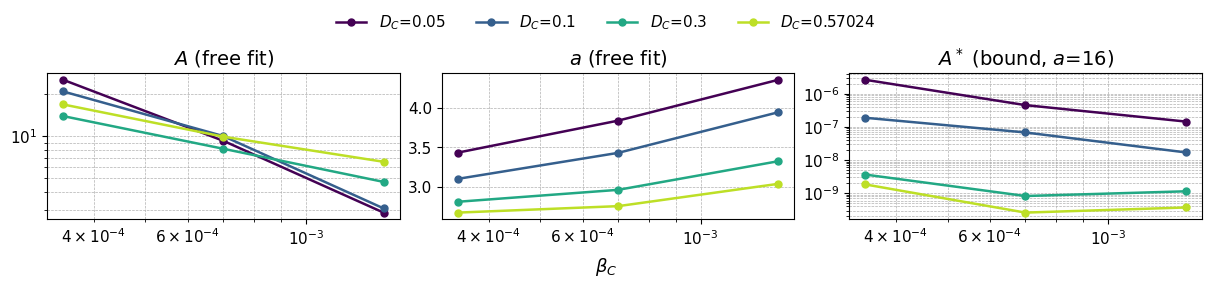

In [25]:
# --- Paper figure: combined total norm (3c) fit parameters A, a, A* vs beta_C, colour = D_C ---
with plt.rc_context(FONT_5E):
    fig, axes = plt.subplots(1, len(param_cols), figsize=(12.0, 2.8), sharex=True, constrained_layout=True)

    for ax, (name, label, logy), tag in zip(axes, param_cols, ["(a)", "(b)", "(c)"]):
        for diffc in diffc_values:
            sub = fits_total[fits_total["diffc"] == diffc].sort_values("beta_c")
            ax.plot(sub["beta_c"], sub[name], marker="o", ms=MS_5E, lw=LW_5E, color=diffc_colors[diffc],
                    label=f"$D_C$={diffc:g}")
        ax.set_xscale("log")
        if logy:
            ax.set_yscale("log")
        # ax.set_ylabel(label)
        ax.set_title(label)
        ax.grid(True, which="both", linestyle="--", linewidth=0.5)

    fig.supxlabel("$\\beta_C$", fontsize=13)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="outside upper center", ncol=len(diffc_values), frameon=False, fontsize=11)
    save_paper_fig(fig, "paper_fit_params_vs_beta_c_total_norm")

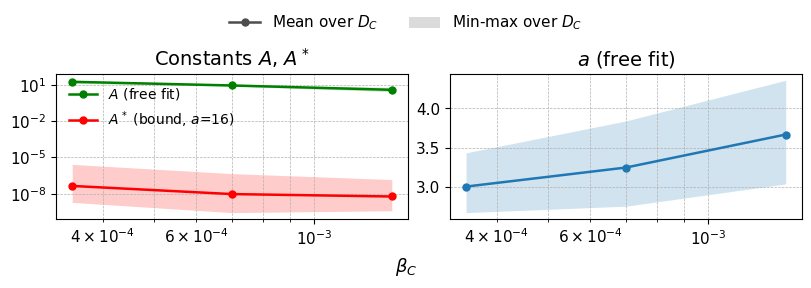

K_fit                          K_envelope                \
             mean        min        max          mean           min   
beta_c                                                                
0.00035  18.78859  13.944044  25.319968  4.277924e-08  1.847949e-09   
0.00070   9.32164   8.149064  10.038358  9.022059e-09  2.610743e-10   
0.00140   4.06045   2.854540   6.580413  5.693678e-09  3.723256e-10   

                      exponent_fit                      
                  max         mean       min       max  
beta_c                                                  
0.00035  2.629479e-06     3.002471  2.669970  3.432865  
0.00070  4.526709e-07     3.245153  2.752118  3.839419  
0.00140  1.448575e-07     3.666217  3.035965  4.359036

In [26]:
# --- Paper figure: (left) A and A*, (right) a, vs one parameter, averaged over the other (3c) ---
# Constants: geometric mean (they span decades, log y-axis). Rate a: arithmetic mean (linear y-axis).
# Band = min-max over the averaged parameter. Colours match the theory overlays: green = free fit, red = bound.
CONST_PARAMS = [("K_fit", "$A$ (free fit)", "green"),
                ("K_envelope", f"$A^*$ (bound, $a$={THEORY_EXP})", "red")]


def plot_params_averaged(x_col, x_label, avg_label, stem):
    names = [name for name, _, _ in CONST_PARAMS]
    const = 10 ** (np.log10(fits_total[names]).groupby(fits_total[x_col]).agg(["mean", "min", "max"]))
    rate = fits_total.groupby(x_col)[["exponent_fit"]].agg(["mean", "min", "max"])["exponent_fit"]

    with plt.rc_context(FONT_5E):
        fig, axes = plt.subplots(1, 2, figsize=(8.0, 2.8), sharex=True, constrained_layout=True)

        ax = axes[0]
        for name, label, color in CONST_PARAMS:
            ax.plot(const.index, const[(name, "mean")], marker="o", ms=MS_5E, lw=LW_5E, color=color, label=label)
            ax.fill_between(const.index, const[(name, "min")], const[(name, "max")], color=color, alpha=0.2, lw=0)
        ax.set_yscale("log")
        ax.set_title("Constants $A$, $A^*$")
        ax.legend(loc="upper left", frameon=False, fontsize=10)

        ax = axes[1]
        ax.plot(rate.index, rate["mean"], marker="o", ms=MS_5E, lw=LW_5E, color="tab:blue")
        ax.fill_between(rate.index, rate["min"], rate["max"], color="tab:blue", alpha=0.2, lw=0)
        ax.set_title("$a$ (free fit)")

        for ax in axes:
            ax.set_xscale("log")
            ax.grid(True, which="both", linestyle="--", linewidth=0.5)
        fig.supxlabel(x_label, fontsize=13)
        fig.legend(handles=[Line2D([], [], color="0.3", marker="o", ms=MS_5E, lw=LW_5E,
                                   label=f"Mean over {avg_label}"),
                            plt.Rectangle((0, 0), 1, 1, color="0.3", alpha=0.2, lw=0,
                                          label=f"Min-max over {avg_label}")],
                   loc="outside upper center", ncol=2, frameon=False, fontsize=11)
        save_paper_fig(fig, stem)
    return const.join(pd.concat({"exponent_fit": rate}, axis=1))


plot_params_averaged("beta_c", "$\\beta_C$", "$D_C$", "paper_fit_params_vs_beta_c_avg_diffc")

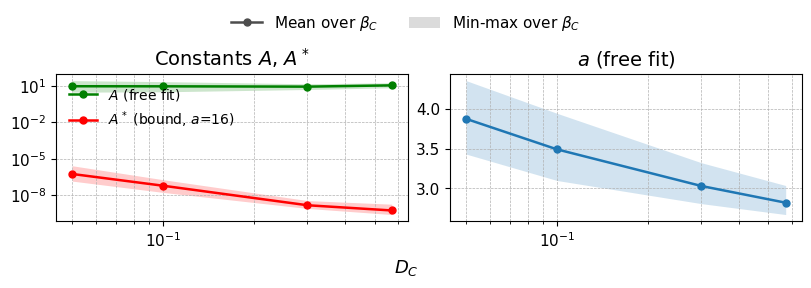

K_fit                         K_envelope                \
              mean       min        max          mean           min   
diffc                                                                 
0.05000   8.755776  2.854540  25.319968  5.565845e-07  1.448575e-07   
0.10000   8.627129  3.060212  20.901851  6.016775e-08  1.702983e-08   
0.30000   8.129879  4.728852  13.944044  1.512011e-09  8.255334e-10   
0.57024  10.336397  6.580413  16.886517  5.642337e-10  2.610743e-10   

                      exponent_fit                      
                  max         mean       min       max  
diffc                                                   
0.05000  2.629479e-06     3.877106  3.432865  4.359036  
0.10000  1.883387e-07     3.491735  3.099256  3.946293  
0.30000  3.659595e-09     3.030262  2.807793  3.323574  
0.57024  1.847949e-09     2.819351  2.669970  3.035965

In [27]:
# --- Paper figure: A, A* and a (3c) vs D_C, averaged over beta_C ---
plot_params_averaged("diffc", "$D_C$", "$\\beta_C$", "paper_fit_params_vs_diffc_avg_beta_c")

## Appendix

**A1.** Prediction snapshots for one scenario (parameters in the figure title). Rows are output times; columns are
the true concentration, the smallest and largest model predictions, and their absolute errors. The validation run
shown has the median largest-model relative L2 error. Uses the 5e styling (`FONT_5E`), so run section 5 first.

<>:19: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
/var/folders/jw/xztj1tg50zn2sk0v8zyt5yqh0000gp/T/ipykernel_69353/104457979.py:19: SyntaxWarning: invalid escape sequence '\e'
  errors = [(f"$|\epsilon|$ for {size.capitalize()}", np.abs(snap_preds[size][run] - truth) / field_max)


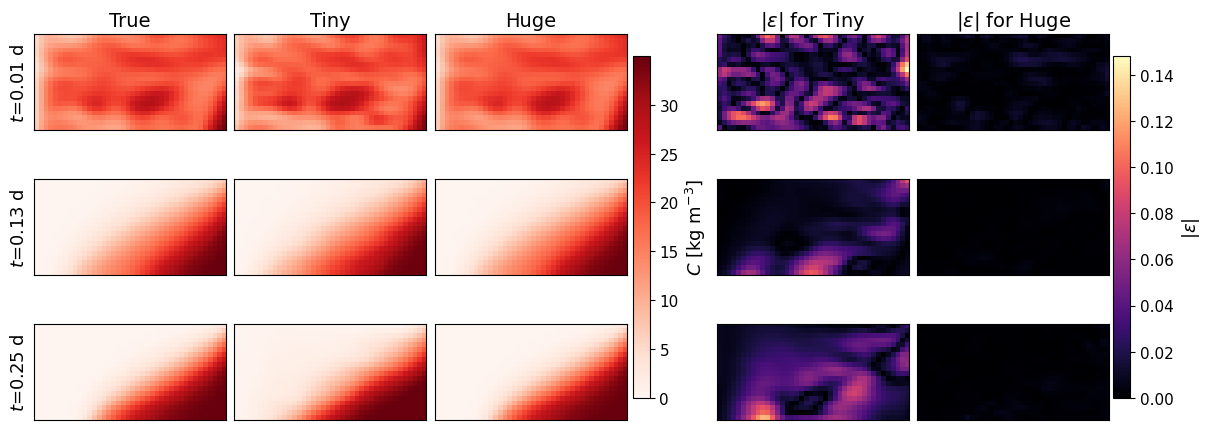

$\beta_C$=0.0007, $D_C$=0.3,


In [28]:
SNAP_SIZES = ["tiny", "huge"]
SNAP_STEPS = [0, 12, 24]   # output indices, t = (k + 1) * DT

hard = (scenarios_df.query("scenario_index not in @EXCLUDE_SCENARIOS")
        .sort_values(["beta_c", "diffc"], ascending=[True, True]).iloc[6])
s = int(hard["scenario_index"])

snap_preds = {}
for size in SNAP_SIZES:
    with np.load(prediction_npz_dir / f"scenario_{s:03d}_{size}.npz") as data:
        snap_true = data["val_targets"][..., 0]
        snap_preds[size] = data["val_preds"][..., 0]
run = int(np.argsort(rel_l2(snap_true, snap_preds[SNAP_SIZES[-1]]))[len(snap_true) // 2])

truth = snap_true[run]
fields = [("True", truth)] + [(size.capitalize(), snap_preds[size][run]) for size in SNAP_SIZES]
# Relative error w.r.t. the max true concentration (pointwise |e|/C blows up where C = 0 in fresh water)
field_max = truth.max()
errors = [(f"$|\epsilon|$ for {size.capitalize()}", np.abs(snap_preds[size][run] - truth) / field_max)
          for size in SNAP_SIZES]
err_max = max(e.max() for _, e in errors)
extent = [0, 2.0, 0, 1.0]

with plt.rc_context(FONT_5E):
    fig, axes = plt.subplots(len(SNAP_STEPS), len(fields) + len(errors), figsize=(12.0, 4.4),
                             constrained_layout=True, squeeze=False)
    for row, k in enumerate(SNAP_STEPS):
        for col, (title, arr) in enumerate(fields + errors):
            ax = axes[row, col]
            is_err = col >= len(fields)
            im = ax.imshow(arr[k], extent=extent, cmap="magma" if is_err else "Reds",
                           vmin=0, vmax=err_max if is_err else field_max)
            ax.set_xticks([])
            ax.set_yticks([])
            if row == 0:
                ax.set_title(title)
            if col == 0:
                ax.set_ylabel(f"$t$={(k + 1) * DT:.2f} d")
            if row == len(SNAP_STEPS) - 1:
                if col == len(fields) - 1:
                    field_im = im
                elif is_err:
                    err_im = im
    fig.colorbar(field_im, ax=axes[:, :len(fields)], shrink=0.8, pad=0.01, label="$C$ [kg m$^{-3}$]")
    fig.colorbar(err_im, ax=axes[:, len(fields):], shrink=0.8, pad=0.01, label=r"$|\epsilon|$")
    # fig.suptitle(f"$\\be=FONT_5E["axes.titta_C$={hard['beta_c']:g}, $D_C$={hard['diffc']:g}, ",
    #             #  f"$R_a$={compute_rayleigh_number(hard['beta_c'], hard['diffc']):.1f}",
    #              fontsizelesize"])
    save_paper_fig(fig, "paper_5d_snapshots")
    print(f"$\\beta_C$={hard['beta_c']:g}, $D_C$={hard['diffc']:g},")